# Eksperymenty - pipeline analizy logów

Ten notebook jest krótką ścieżką kontrolną projektu: od konfiguracji wejścia, przez analizę logów, po eksport i podstawowe pomiary równoległe. Ma pokazać, że poszczególne moduły projektu współpracują ze sobą w jednym, powtarzalnym przepływie.

## Cel notebooka

W tym notebooku sprawdzamy trzy rzeczy:

- poprawność parsowania i filtrowania logów,
- podstawowe statystyki potrzebne do raportu,
- zachowanie wariantów OpenMP-like i MPI na tym samym wejściu.

Wyniki zapisane w komórkach są częścią dokumentacji eksperymentu, dlatego można je traktować jako punkt odniesienia dla kolejnych uruchomień.

In [1]:
from datetime import datetime
from pathlib import Path

from config import DEFAULT_INPUT_LOG, DEFAULT_LEVELS, DEFAULT_PHRASES, REPORTS_DIR, HADOOP_LOG_2K
from domain.models import AnalysisConfig
from processing.analyzer import analyze_log_file
from report import result_to_dict, save_filtered_lines_csv, save_report_json
from visualization.plots import plot_errors_per_hour

## 1) Konfiguracja analizy

In [2]:
INPUT_LOG = str(DEFAULT_INPUT_LOG)
PHRASES = DEFAULT_PHRASES + ("FATAL", "CRITICAL")
LEVELS_FILTER = DEFAULT_LEVELS
DATE_FROM = datetime(2005, 1, 1, 0, 0, 0)
DATE_TO = datetime(2030, 1, 1, 0, 0, 0)

config = AnalysisConfig.from_iterables(
    phrases=PHRASES,
    levels=LEVELS_FILTER,
    date_from=DATE_FROM,
    date_to=DATE_TO,
)

## 2) Uruchomienie analizy

In [3]:
result = analyze_log_file(INPUT_LOG, config)
report = result_to_dict(result)
report["summary"]

{'total_lines': 2000,
 'parsed_lines': 2000,
 'parse_errors': 0,
 'matched_lines': 2000}

## 3) Zliczenia fraz

In [4]:
report["phrase_counts"]

{'ERROR': 154, 'WARNING': 0, 'INFO': 6, 'FATAL': 0, 'CRITICAL': 0}

## 4) Zliczenia poziomów logów

In [5]:
report["level_counts"]

{'ERROR': 150, 'FATAL': 2, 'INFO': 1040, 'WARN': 808}

## 5) Podgląd przefiltrowanych linii

In [6]:
result.filtered_lines[:10]

['2015-10-18 18:01:47,978 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: Created MRAppMaster for application appattempt_1445144423722_0020_000001',
 '2015-10-18 18:01:48,963 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: Executing with tokens:',
 '2015-10-18 18:01:48,963 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: Kind: YARN_AM_RM_TOKEN, Service: , Ident: (appAttemptId { application_id { id: 20 cluster_timestamp: 1445144423722 } attemptId: 1 } keyId: -127633188)',
 '2015-10-18 18:01:49,228 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: Using mapred newApiCommitter.',
 '2015-10-18 18:01:50,353 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: OutputCommitter set in config null',
 '2015-10-18 18:01:50,509 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: OutputCommitter is org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter',
 '2015-10-18 18:01:50,556 INFO [main] org.apache.hadoop.yarn.event.AsyncDispatcher

## 6) Zdarzenia ERROR na godzinę

In [7]:
report["errors_per_hour"]

{'2015-10-18 18:00': 150}

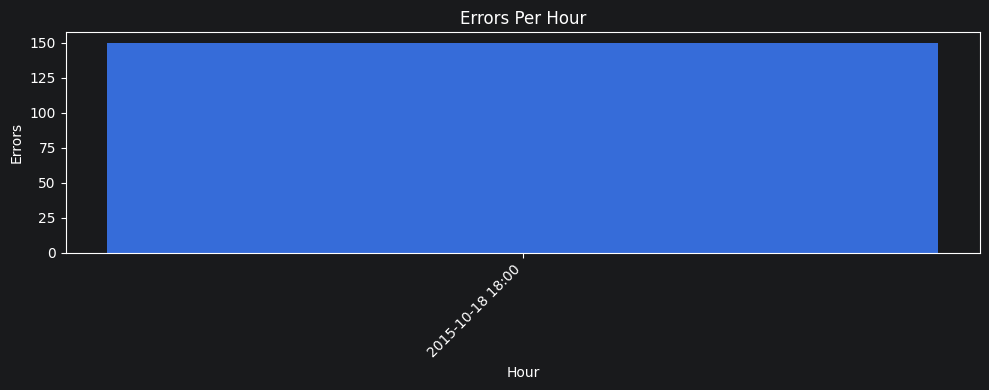

In [8]:
plot_errors_per_hour(result.errors_per_hour)

### Interpretacja wyników bazowych

Pierwsze sekcje potwierdzają, ile linii zostało sparsowanych, jakie poziomy logów występują w danych oraz jak rozkładają się zdarzenia `ERROR` w czasie. To jest baza porównawcza dla dalszych benchmarków: najpierw upewniamy się, że dane i filtry są poprawne, dopiero potem mierzymy warianty równoległe.

## 7) Eksport wyników do plików

In [9]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
json_path = REPORTS_DIR / "notebook_report.json"
csv_path = REPORTS_DIR / "notebook_filtered.csv"
save_report_json(result, str(json_path))
save_filtered_lines_csv(result, str(csv_path))
json_path, csv_path

(WindowsPath('C:/pycharm_pro_projects/prir_projekt/reports/notebook_report.json'),
 WindowsPath('C:/pycharm_pro_projects/prir_projekt/reports/notebook_filtered.csv'))

In [10]:
from parallel.openmp.tokenizer import (
    tokenize_and_encode
)

from parallel.openmp.histogram import (
    build_histogram
)

from parallel.openmp.benchmark import (
    benchmark_openmp
)

with open(
        HADOOP_LOG_2K,
        encoding="utf-8"
) as file:

    lines = file.readlines()

encoded, vocabulary = (
    tokenize_and_encode(
        lines
    )
)

histogram = build_histogram(
    encoded,
    len(vocabulary)
)

benchmark_openmp(
    lines
)

{'time': 0.00740369999948598,
 'tokens': 29145,
 'vocabulary_size': 2228,
 'workers': 4,
 'local_dicts': 4,
 'global_token_total_from_reduction': 29145,
 'global_token_total_from_histogram': 29145}

## 8) Benchmark OpenMP-like i MPI

Ta część porównuje czas wykonania, przyspieszenie (speedup) i efektywność równoleglenia (efficiency). OpenMP-like wykorzystuje równoległą tokenizację w Pythonie, a MPI korzysta z `mpi4py` lub z trybu jednego procesu.

In [11]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import DEFAULT_INPUT_LOG
from parallel.openmp.benchmark import benchmark_openmp
from parallel.mpi.runner import run_mpi_token_count

with open(DEFAULT_INPUT_LOG, "r", encoding="utf-8") as h:
    lines = h.readlines()

len(lines)

2000

In [12]:
openmp_workers = [1, 2, 4, 8]
openmp_results = []

for w in openmp_workers:
    r = benchmark_openmp(lines, workers=w)
    openmp_results.append(r)

df_openmp = pd.DataFrame(openmp_results).sort_values("workers")
T1 = float(df_openmp.loc[df_openmp["workers"] == 1, "time"].iloc[0])
df_openmp["speedup"] = T1 / df_openmp["time"]
df_openmp["efficiency"] = df_openmp["speedup"] / df_openmp["workers"]
df_openmp

,time,tokens,vocabulary_size,workers,local_dicts,global_token_total_from_reduction,global_token_total_from_histogram,speedup,efficiency
0,0.006655,29145,2228,1,1,29145,29145,1.000000,1.000000
1,0.006695,29145,2228,2,2,29145,29145,0.993966,0.496983
2,0.006696,29145,2228,4,4,29145,29145,0.993921,0.248480
3,0.007386,29145,2228,8,8,29145,29145,0.901017,0.112627


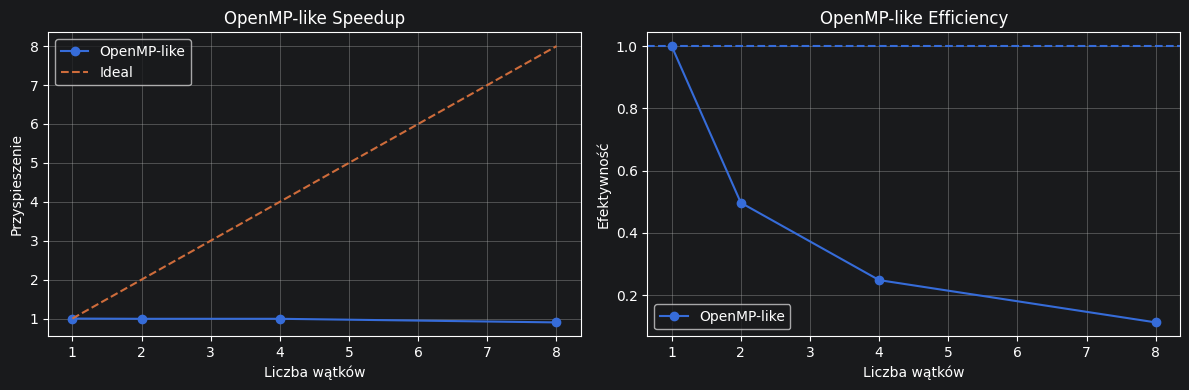

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(df_openmp["workers"], df_openmp["speedup"], marker="o", label="OpenMP-like")
ax[0].plot(df_openmp["workers"], df_openmp["workers"], linestyle="--", label="Ideal")
ax[0].set_title("OpenMP-like Speedup")
ax[0].set_xlabel("Liczba wątków")
ax[0].set_ylabel("Przyspieszenie")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(df_openmp["workers"], df_openmp["efficiency"], marker="o", label="OpenMP-like")
ax[1].axhline(1.0, linestyle="--")
ax[1].set_title("OpenMP-like Efficiency")
ax[1].set_xlabel("Liczba wątków")
ax[1].set_ylabel("Efektywność")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

### MPI

Komórka działa w trybie jednego procesu oraz po uruchomieniu notebooka lub skryptu przez `mpiexec`. Pełne pomiary dla wielu procesów najwygodniej wykonać z poziomu CLI.

In [14]:
mpi_result = run_mpi_token_count(lines)
mpi_result

{'world_size': 1,
 'rank': 0,
 'tokens': 29145,
 'vocabulary_size': 2228,
 'time': 0.05090109999946435,
 'mode': 'mpi-root'}

### Wniosek z części równoległej

OpenMP-like pokazuje koszt równoległej tokenizacji i redukcji w Pythonie, natomiast MPI pozwala uruchomić ten sam schemat w modelu wielu procesów. Dla małych plików narzut uruchomienia workerów lub procesów może być większy niż zysk z równoległości; większe dane lepiej pokazują realne różnice między podejściami.

Dla pełnych wykresów MPI z różną liczbą procesów uruchom polecenia:

```bash
mpiexec -n 1 python main.py --input data/raw/Hadoop_2k.log --parallel-mode mpi
mpiexec -n 2 python main.py --input data/raw/Hadoop_2k.log --parallel-mode mpi
mpiexec -n 4 python main.py --input data/raw/Hadoop_2k.log --parallel-mode mpi
mpiexec -n 8 python main.py --input data/raw/Hadoop_2k.log --parallel-mode mpi
```